In [4]:
import os
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
from torch import nn
from torch.nn import Module, Sequential
from torch.nn import Conv2d, ConvTranspose2d
from torch.nn import BatchNorm2d, ReLU, LeakyReLU, Tanh
from pytorch_msssim import ssim
from torchvision import datasets
from torch.utils.data import DataLoader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

mnist = datasets.MNIST(
    root='./data',
    train=True, 
    download=True, 
    transform=transform  
)

dataloader = DataLoader(
    mnist,
    batch_size=64,
    shuffle=True 
)

class Generator(Module):
    def __init__(self, z_dim, h_dim, img_channels):
        super(Generator, self).__init__()
        self.z_dim = z_dim
        self.generator = Sequential(
            self.generator_block(z_dim, h_dim),
            self.generator_block(h_dim, h_dim * 2, kernel_size=4, stride=1),
            self.generator_block(h_dim * 2, h_dim * 4),
            self.generator_block(h_dim * 4, img_channels, kernel_size=4, output_layer=True),
        )

    def generator_block(self, input_dims, output_dims, kernel_size=3, stride=2, output_layer=False):
        if output_layer:
            return Sequential(
                ConvTranspose2d(input_dims, output_dims, kernel_size, stride),
                Tanh()
            )
        else:
            return Sequential(
                ConvTranspose2d(input_dims, output_dims, kernel_size, stride),
                BatchNorm2d(output_dims),
                ReLU(inplace=True)
            )

    def forward(self, noise):
        noise = noise.view(len(noise), self.z_dim, 1, 1)
        return self.generator(noise)

class Critic(Module):
    def __init__(self, h_dim, img_channels):
        super(Critic, self).__init__()
        self.critic = Sequential(
            self.critic_block(img_channels, h_dim),
            self.critic_block(h_dim, h_dim * 2),
            self.critic_block(h_dim * 2, 1, output_layer=True),
        )

    def critic_block(self, input_dims, output_dims, kernel_size=4, stride=2, output_layer=False):
        if output_layer:
            return Sequential(
                Conv2d(input_dims, output_dims, kernel_size, stride)
            )
        else:
            return Sequential(
                Conv2d(input_dims, output_dims, kernel_size, stride),
                BatchNorm2d(output_dims),
                LeakyReLU(0.2, inplace=True)
            )

    def forward(self, image):
        critic_pred = self.critic(image)
        return critic_pred.view(len(critic_pred), -1)


def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
        torch.nn.init.constant_(m.bias, 0)

def generate_noise(batch_size, z_dim, device=device):
    return torch.randn(batch_size, z_dim, device=device)

def generator_loss(fake_scores):
    return -torch.mean(fake_scores)


ZDIM = 64
HDIM = 128
IMG_CHANNELS = 1
generator = Generator(z_dim=ZDIM, h_dim=HDIM, img_channels=IMG_CHANNELS).to(device)
critic = Critic(h_dim=HDIM, img_channels=IMG_CHANNELS).to(device)
LR = 2e-4
generator_optim = torch.optim.RMSprop(generator.parameters(), lr=LR)
critic_optim = torch.optim.RMSprop(critic.parameters(), lr=LR)
Epochs = 50
critic_iter = 5
clip_value = 0.01


for epoch in range(Epochs):
    gen_losses = []
    crit_losses = []

    for batch_idx, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        curr_batch_size = real_imgs.size(0)


        for _ in range(critic_iter):
            noise = generate_noise(curr_batch_size, ZDIM, device)
            fake_imgs = generator(noise).detach()
            critic_real = critic(real_imgs)
            critic_fake = critic(fake_imgs)
            crit_loss = torch.mean(critic_fake) - torch.mean(critic_real)

            critic_optim.zero_grad()
            crit_loss.backward()
            critic_optim.step()
            for p in critic.parameters():
                p.data.clamp_(-clip_value, clip_value)

        crit_losses.append(crit_loss.item())

        noise = generate_noise(curr_batch_size, ZDIM, device)
        fake_imgs = generator(noise)
        gen_score = critic(fake_imgs)
        gen_loss = generator_loss(gen_score)
        generator_optim.zero_grad()
        gen_loss.backward()
        generator_optim.step()
        gen_losses.append(gen_loss.item())
        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch+1}/{Epochs}] Batch {batch_idx}/{len(dataloader)} | "
                  f"D Loss: {crit_loss.item():.4f}, G Loss: {gen_loss.item():.4f}")



Epoch [1/50] Batch 0/938 | D Loss: -0.0929, G Loss: 0.0414
Epoch [1/50] Batch 100/938 | D Loss: -0.2823, G Loss: 0.0392
Epoch [1/50] Batch 200/938 | D Loss: -0.2120, G Loss: -0.0540
Epoch [1/50] Batch 300/938 | D Loss: -0.2254, G Loss: 0.1223
Epoch [1/50] Batch 400/938 | D Loss: -0.1856, G Loss: -0.0476
Epoch [1/50] Batch 500/938 | D Loss: -0.1837, G Loss: -0.1800
Epoch [1/50] Batch 600/938 | D Loss: -0.0929, G Loss: 0.1106
Epoch [1/50] Batch 700/938 | D Loss: -0.1445, G Loss: -0.0155
Epoch [1/50] Batch 800/938 | D Loss: -0.0843, G Loss: 0.0200
Epoch [1/50] Batch 900/938 | D Loss: -0.1080, G Loss: 0.1378
Epoch [2/50] Batch 0/938 | D Loss: -0.0901, G Loss: -0.0643
Epoch [2/50] Batch 100/938 | D Loss: -0.0753, G Loss: -0.1212
Epoch [2/50] Batch 200/938 | D Loss: -0.0530, G Loss: -0.0755
Epoch [2/50] Batch 300/938 | D Loss: -0.0716, G Loss: -0.0076
Epoch [2/50] Batch 400/938 | D Loss: -0.0878, G Loss: -0.0562
Epoch [2/50] Batch 500/938 | D Loss: -0.0714, G Loss: 0.1241
Epoch [2/50] Batch 

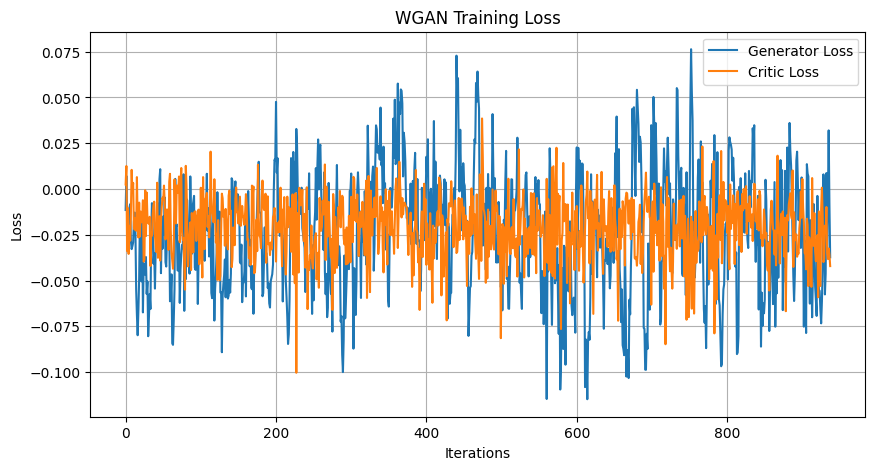

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(gen_losses, label="Generator Loss")
plt.plot(crit_losses, label="Critic Loss")
plt.title("WGAN Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


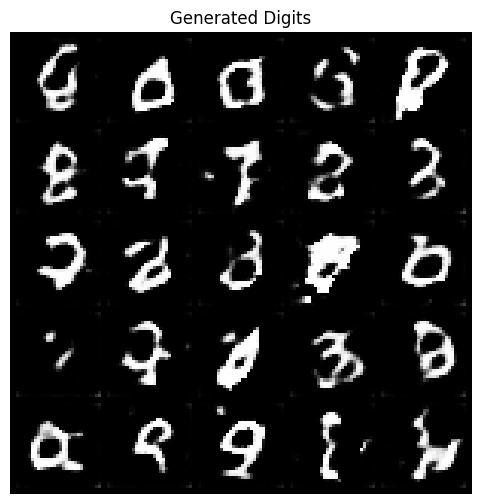

In [6]:
import torchvision

def show_generated_images(generator, z_dim, device, n=25):
    generator.eval()
    noise = generate_noise(n, z_dim, device)
    fake_imgs = generator(noise).detach().cpu()
    fake_imgs = (fake_imgs + 1) / 2

    grid = torchvision.utils.make_grid(fake_imgs, nrow=5, padding=2)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.title("Generated Digits")
    plt.show()

show_generated_images(generator, ZDIM, device)
